## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Instacart analytical table

In [2]:
df_instacart = pd.read_parquet("../data/processed/instacart.parquet")
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [3]:
df_instacart.shape

(1384706, 22)

In [4]:
df_instacart.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division'],
      dtype='str')

## 1. Visualizing Orders by Day of Week

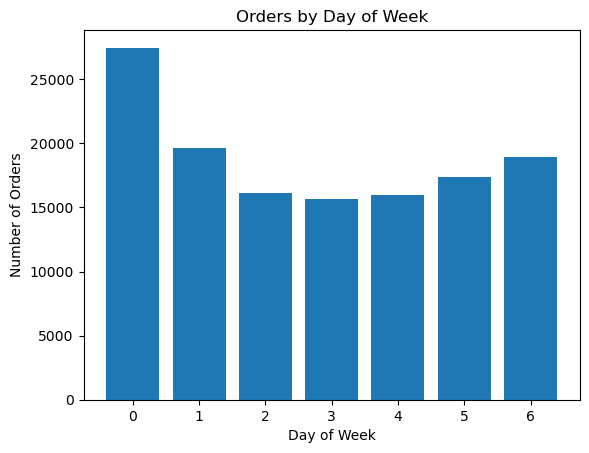

In [8]:
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby("order_dow")
    .size()
)

# orders_by_day
# type(orders_by_day)

plt.figure()
plt.bar(orders_by_day.index, orders_by_day.values)
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.title("Orders by Day of Week")
plt.show()


## 2. Visualizing Orders by Hour of Day

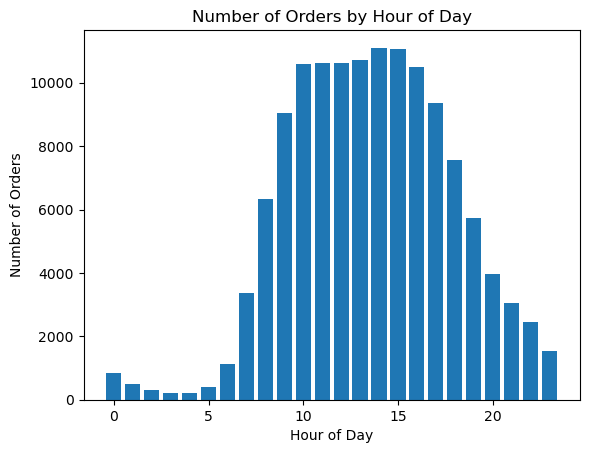

In [10]:
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

plt.figure()
plt.bar(orders_by_hour.index, orders_by_hour.values)
plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

## 3: Visualizing the Most Popular Departments

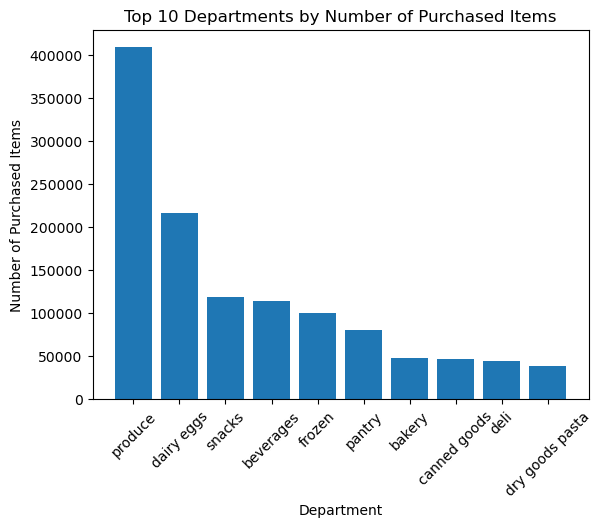

In [14]:
top_departments = df_instacart["department"].value_counts().head(10)

plt.figure()
plt.bar(top_departments.index, top_departments.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Department")
plt.ylabel("Number of Purchased Items")
plt.xticks(rotation=45)
plt.show()

### Creating the improved chart

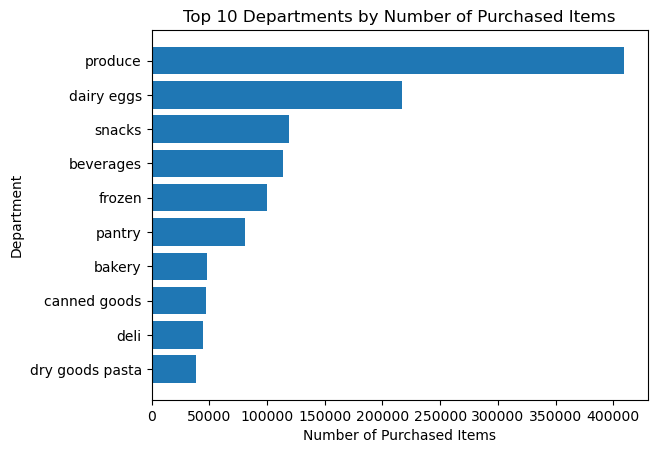

In [15]:
top_departments_sorted = df_instacart["department"].value_counts().head(10).sort_values()

plt.figure()
plt.barh(top_departments_sorted.index, top_departments_sorted.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Number of Purchased Items")
plt.ylabel("Department")
plt.show()

## 5: Visualizing the Distribution of Prices

In [16]:
df_instacart['prices'].describe()

count    1.384618e+06
mean     1.411711e+01
std      6.802253e+02
min      1.000000e+00
25%      4.300000e+00
50%      7.400000e+00
75%      1.130000e+01
max      9.999900e+04
Name: prices, dtype: float64

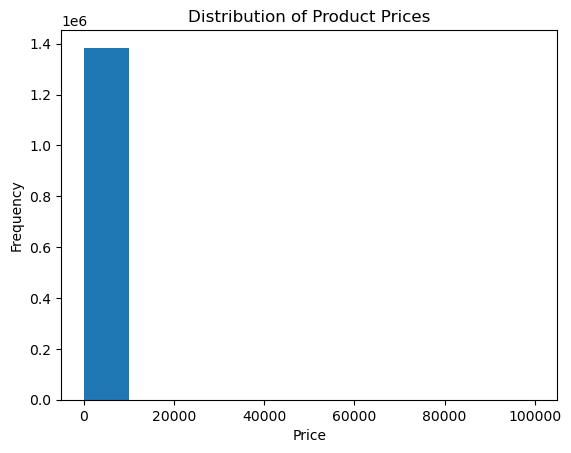

In [22]:
plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=10)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Alternative 1: Using the 99th percentile

In [23]:
upper_limit = df_instacart["prices"].quantile(0.99)
upper_limit

np.float64(18.1)

In [24]:
df_prices_q = df_instacart[df_instacart["prices"] <= upper_limit]
df_prices_q["prices"].describe()

count    1.370887e+06
mean     7.668451e+00
std      4.039330e+00
min      1.000000e+00
25%      4.200000e+00
50%      7.300000e+00
75%      1.120000e+01
max      1.810000e+01
Name: prices, dtype: float64

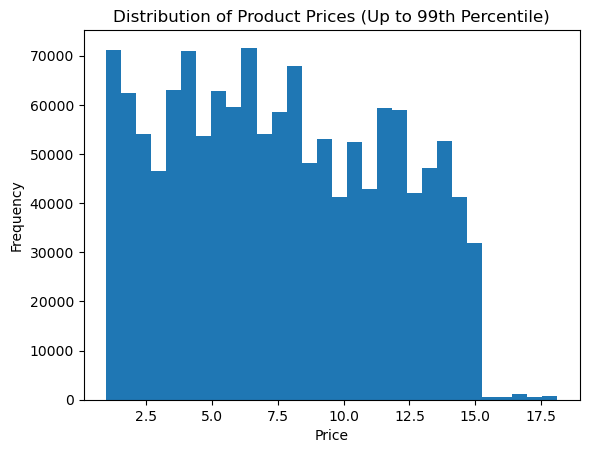

In [25]:
plt.figure()
plt.hist(df_prices_q["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Up to 99th Percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Alternative 2: Using the 95th percentile

In [26]:
upper_limit_95 = df_instacart["prices"].quantile(0.95)
upper_limit_95

np.float64(14.3)

In [27]:
df_prices_q95 = df_instacart[df_instacart["prices"] <= upper_limit_95]
df_prices_q95["prices"].describe()

count    1.316686e+06
mean     7.373599e+00
std      3.843880e+00
min      1.000000e+00
25%      4.100000e+00
50%      7.100000e+00
75%      1.060000e+01
max      1.430000e+01
Name: prices, dtype: float64

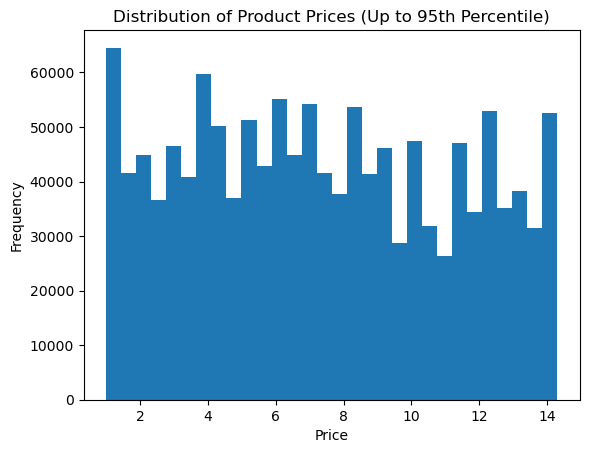

In [28]:
plt.figure()
plt.hist(df_prices_q95["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Up to 95th Percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Alternative 3: Keeping all rows but zooming the x-axis

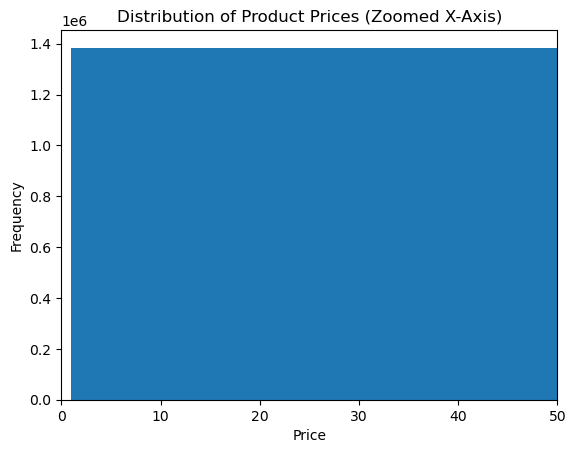

In [35]:
plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=30)
plt.xlim(0, 50)
plt.title("Distribution of Product Prices (Zoomed X-Axis)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Alternative 4: Using z-scores

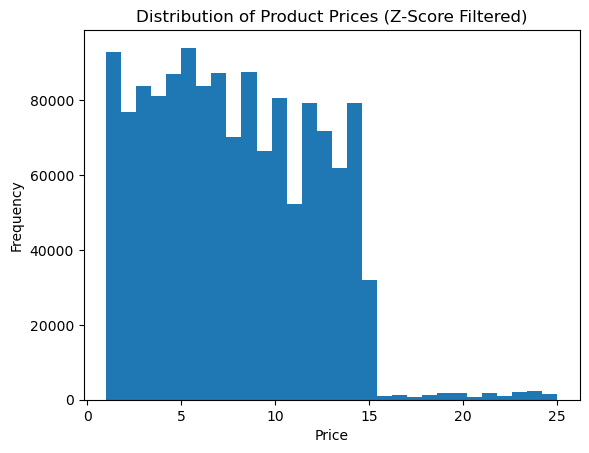

In [38]:
mean_price = df_instacart["prices"].mean()
std_price = df_instacart["prices"].std()

z_scores = (df_instacart["prices"] - mean_price) / std_price
# type(z_scores)
# z_scores.describe()

df_prices_z = df_instacart[z_scores.abs() < 3]

plt.figure()
plt.hist(df_prices_z["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Z-Score Filtered)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Example 6: Visualizing Average Price by Department

In [39]:
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

avg_price_by_department

department
snacks              4.272277
other               7.184457
dry goods pasta     7.388252
household           7.402065
canned goods        7.530263
beverages           7.660526
babies              7.682672
deli                7.768707
international       7.799126
frozen              7.801781
bakery              7.833023
pets                7.867823
pantry              7.955316
personal care       7.989259
produce             7.997862
breakfast           8.090261
alcohol             8.126044
bulk                8.211626
missing             8.599139
meat seafood       16.202349
dairy eggs         48.606962
Name: prices, dtype: float64

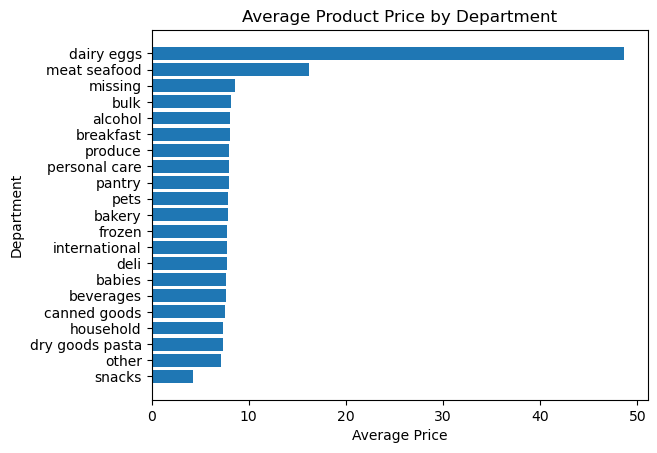

In [40]:
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure()
plt.barh(avg_price_by_department.index, avg_price_by_department.values)
plt.title("Average Product Price by Department")
plt.xlabel("Average Price")
plt.ylabel("Department")
plt.show()

## Example 7: Visualizing Reorder Rate by Region

In [41]:
reorder_rate_by_region = (
    df_instacart
    .groupby("region")["reordered"]
    .mean()
    .sort_values(ascending=True)
)

reorder_rate_by_region

region
South        0.596392
Midwest      0.598615
West         0.599062
Northeast    0.602097
Name: reordered, dtype: float64

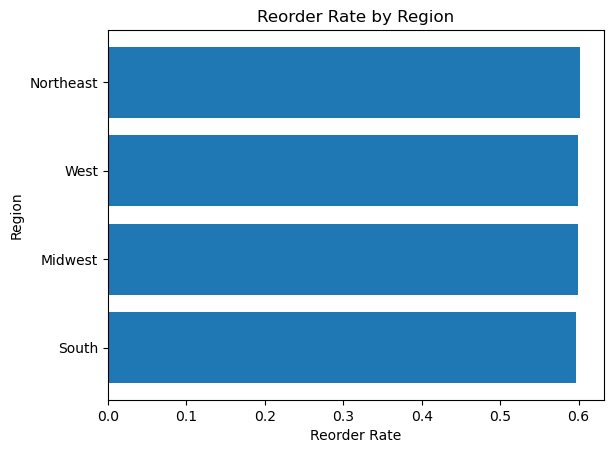

In [42]:
reorder_rate_by_region = (
    df_instacart
    .groupby("region")["reordered"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure()
plt.barh(reorder_rate_by_region.index, reorder_rate_by_region.values)
plt.title("Reorder Rate by Region")
plt.xlabel("Reorder Rate")
plt.ylabel("Region")
plt.show()

## Example 8: Visualizing Relationship Between Age and Income

In [45]:

customer_profile = df_instacart[
    ["First Name", "Surname", "Age", "income"]
].drop_duplicates()

print(type(customer_profile))
print(customer_profile.shape)

customer_profile.head()

<class 'pandas.DataFrame'>
(131206, 4)


,First Name,Surname,Age,income
0,Linda,Nguyen,31,40423
11,Norma,Chapman,68,64940
42,Janet,Lester,75,115242
51,Peter,Villegas,39,89095
60,Anna,Allison,32,88603


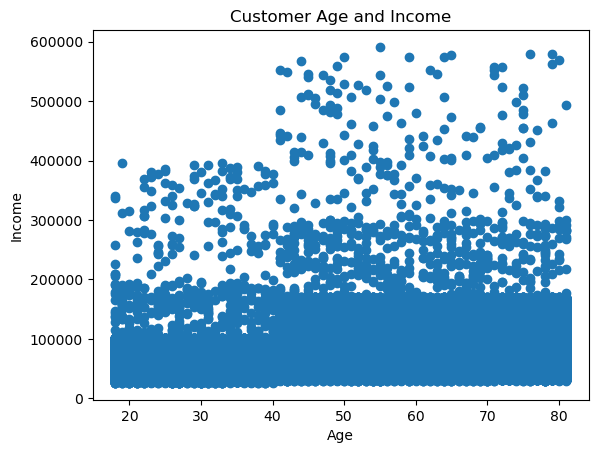

In [44]:
customer_profile = df_instacart[
    ["First Name", "Surname", "Age", "income"]
].drop_duplicates()

plt.figure()
plt.scatter(customer_profile["Age"], customer_profile["income"])
plt.title("Customer Age and Income")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()